In [1]:
list_of_packages <- c("ggplot2", "dplyr", "tidyr", "circlize", "patchwork")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                package,
                character.only = TRUE,
                quietly = TRUE,
                
                warn.conflicts = FALSE
            )
        )
    )
}
    

In [2]:
figures_path <- file.path("../figures/NF0014/")
# Get the current working directory and find Git root
find_git_root <- function() {
    # Get current working directory
    cwd <- getwd()

    # Check if current directory has .git
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }

    # If not, search parent directories
    current_path <- cwd
    while (dirname(current_path) != current_path) {  # While not at root
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }

    # If no Git root found, stop with error
    stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()
cat("Git root directory:", root_dir, "\n")


Git root directory: /home/lippincm/Documents/fork2_NF1_organoid_profile_analysis 


In [3]:
figures_path <- file.path(root_dir,"1.EDA/figures/linear_modeling/")
if (!dir.exists(figures_path)) {
    dir.create(figures_path, recursive = TRUE)
}

In [4]:
organoid_fs_lm_results_path <- file.path(
    root_dir,
    "1.EDA/results/linear_modeling/organoid_fs.parquet"
)
organoid_fs_lm_results_df <- arrow::read_parquet(
    organoid_fs_lm_results_path
)
head(organoid_fs_lm_results_df)

patient,treatment,feature,rsquared,rsquared_adj,fvalue,pvalue,coefficient,intercept,Compartment,Channel,Feature_type,Measurement,pvalue_fdr
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
NF0014_T1,Trametinib_1uM,Organoid_AGP_Granularity_1,0.0001463996,-0.0231060097,0.006296105,0.93712396,0.04338307,-0.4432865,Organoid,AGP,Granularity,1,NA
NF0014_T1,Trametinib_1uM,Organoid_AGP_Granularity_10,0.0046082949,-0.0185403494,0.199074074,0.65770805,1.00000000,3.0000000,Organoid,AGP,Granularity,10,NA
NF0014_T1,Trametinib_1uM,Organoid_AGP_Granularity_11,0.0228571429,0.0001328904,1.005847953,0.32151023,2.00000000,2.0000000,Organoid,AGP,Granularity,11,NA
NF0014_T1,Trametinib_1uM,Organoid_AGP_Granularity_12,0.0710227273,0.0494186047,3.287461774,0.07679492,3.75000000,2.2500000,Organoid,AGP,Granularity,12,NA
NF0014_T1,Trametinib_1uM,Organoid_AGP_Granularity_13,0.0075120192,-0.0155690966,0.325461701,0.57131300,1.25000000,2.7500000,Organoid,AGP,Granularity,13,NA
NF0014_T1,Trametinib_1uM,Organoid_AGP_Granularity_14,0.0018796992,-0.0213324008,0.080979284,0.77734068,0.50000000,1.5000000,Organoid,AGP,Granularity,14,NA


Warning message:
“Removed 896 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 896 rows containing missing values or values outside the scale range
(`geom_point()`).”


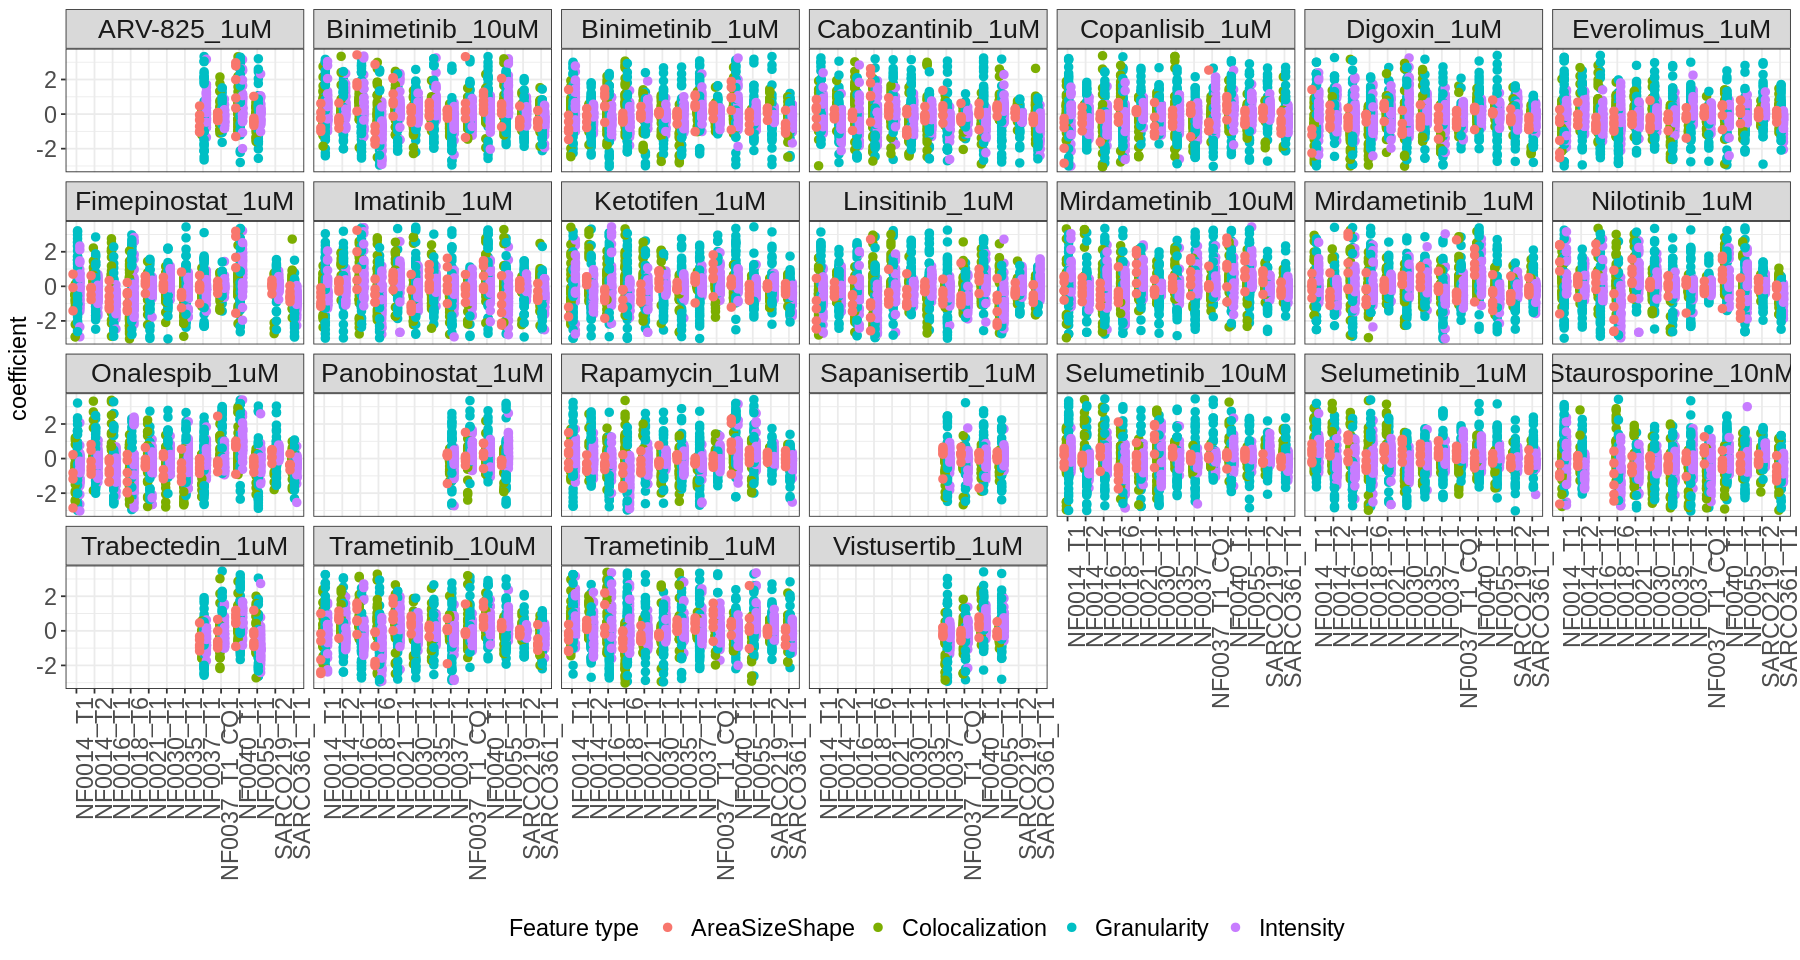

In [5]:
width <- 15
height <- 8
options(repr.plot.width = width, repr.plot.height = height)
coeff_plot <- (
    ggplot(organoid_fs_lm_results_df,
        aes(x = patient , y = coefficient, color = Feature_type))
    + geom_point(
        position = position_dodge(width = 0.5),
        size = 2
    )
    + theme_bw()
    + ylim(
        quantile(organoid_fs_lm_results_df$coefficient, 0.01),
        quantile(organoid_fs_lm_results_df$coefficient, 0.99)
        )
    + facet_wrap( ~ treatment, ncol = 7)
    + theme(
        axis.text.x = element_text(angle = 90, hjust = 1, size = 14),
        legend.position = "bottom",
        axis.title.x = element_blank(),
        axis.text.y = element_text(size = 14),
        axis.title.y = element_text(size = 14),
        strip.text = element_text(size = 16),
        legend.text = element_text(size = 14),
        legend.title = element_text(size = 14)
        
    )
    + guides(
        color = guide_legend(nrow = 1, title = "Feature type"),    )

)
ggsave(
    filename = file.path(figures_path, "organoid_linear_modeling_results_all_patients.png"),
    plot = coeff_plot,
    width = width,
    height = height
)
coeff_plot

In [6]:
patients <- unique(organoid_fs_lm_results_df$patient)
for (patient_id in patients) {
    patient_file_path <- file.path(
            figures_path,
            patient_id
        )
        if (!dir.exists(patient_file_path)) {
            dir.create(patient_file_path, recursive = TRUE)
        }
    organoid_fs_lm_results_df_patient <- organoid_fs_lm_results_df %>%
        filter(patient == patient_id)
    width <- 14
    height <- 14
    options(repr.plot.width = width, repr.plot.height = height)
    plot <- (
        ggplot(organoid_fs_lm_results_df_patient,
            aes(x = Feature_type, y = coefficient, fill = Feature_type))
        + geom_boxplot(
            position = position_dodge(width = 0.5),
            size = 0.1,
        )
        + theme_bw()
        + labs(
            x = "Feature type",
            y = "Coefficient",
            title = paste("Linear modeling results for", patient_id)
        )
        + ylim(
                quantile(organoid_fs_lm_results_df_patient$coefficient, 0.01),
                quantile(organoid_fs_lm_results_df_patient$coefficient, 0.99)
                )
        + facet_wrap( ~ treatment, scales = "free_y", ncol = 4)
        + theme(
            axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 14),
            axis.text.y = element_text(size = 14),
            axis.title.x = element_text(size = 14),
            axis.title.y = element_text(size = 14),
            plot.title = element_text(size = 14, hjust = 0.5),
            legend.text = element_text(size = 14),
            legend.title = element_text(size = 14),
            legend.position = "bottom",
            strip.text = element_text(size = 14)
        )
        + guides(
            fill = guide_legend(title = "")
        )
    )
    ggsave(
        filename = file.path(patient_file_path, paste0("organoid_linear_modeling_results_", patient_id, ".png")),
        plot = plot,
        width = width,
        height = height
    )
}

Warning message:
“Removed 66 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 66 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 62 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 66 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 64 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 66 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 66 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 82 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 82 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 82 rows containing non-finite outside the scale range
(`stat_boxp

## Single cell plots

In [7]:
sc_fs_lm_results_path <- file.path(
    root_dir,
    "1.EDA/results/linear_modeling/sc_fs.parquet"
)
sc_fs_lm_results_df <- arrow::read_parquet(
    sc_fs_lm_results_path
)
head(sc_fs_lm_results_df)

patient,treatment,feature,rsquared,rsquared_adj,fvalue,pvalue,coefficient,intercept,Compartment,Channel,Feature_type,Measurement,pvalue_fdr
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
NF0014_T1,Trametinib_1uM,Cell_AGP_Granularity_1,0.0008348423,-0.0008416093,0.4979818,4.806640e-01,0.2448159,0.2352635,Cell,AGP,Granularity,1,NA
NF0014_T1,Trametinib_1uM,Cell_AGP_Granularity_2,0.1136353294,0.1121481404,76.4094718,2.340954e-17,4.4733019,1.2644077,Cell,AGP,Granularity,2,NA
NF0014_T1,Trametinib_1uM,Cell_AGP_Granularity_3,0.0721467313,0.0705899305,46.3429438,2.426457e-11,3.0315921,0.9486552,Cell,AGP,Granularity,3,NA
NF0014_T1,Trametinib_1uM,Cell_AGP_Intensity_MassDisplacement,0.0030687395,0.0013960361,1.8345987,1.760986e-01,0.3137874,0.1907400,Cell,AGP,Intensity,MassDisplacement,NA
NF0014_T1,Trametinib_1uM,Cell_AGP_Intensity_MaxIntensity,0.0503294112,0.0487360042,31.5860356,2.932312e-08,1.9454625,0.3401554,Cell,AGP,Intensity,MaxIntensity,NA
NF0014_T1,Trametinib_1uM,Cell_AGP_Intensity_MaxIntensityEdge,0.0341193532,0.0324987481,21.0534651,5.448326e-06,1.3517189,0.2046919,Cell,AGP,Intensity,MaxIntensityEdge,NA


In [8]:
# drop the NA in Compartment
sc_fs_lm_results_df <- sc_fs_lm_results_df %>%
    filter(!is.na(Compartment))


In [9]:
# make the compartments a factor
sc_fs_lm_results_df$Compartment <- factor(
    sc_fs_lm_results_df$Compartment,
    levels = c("Nuclei", "Cytoplasm", "Cell")
)

Warning message:
“Removed 1546 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1546 rows containing missing values or values outside the scale range
(`geom_point()`).”


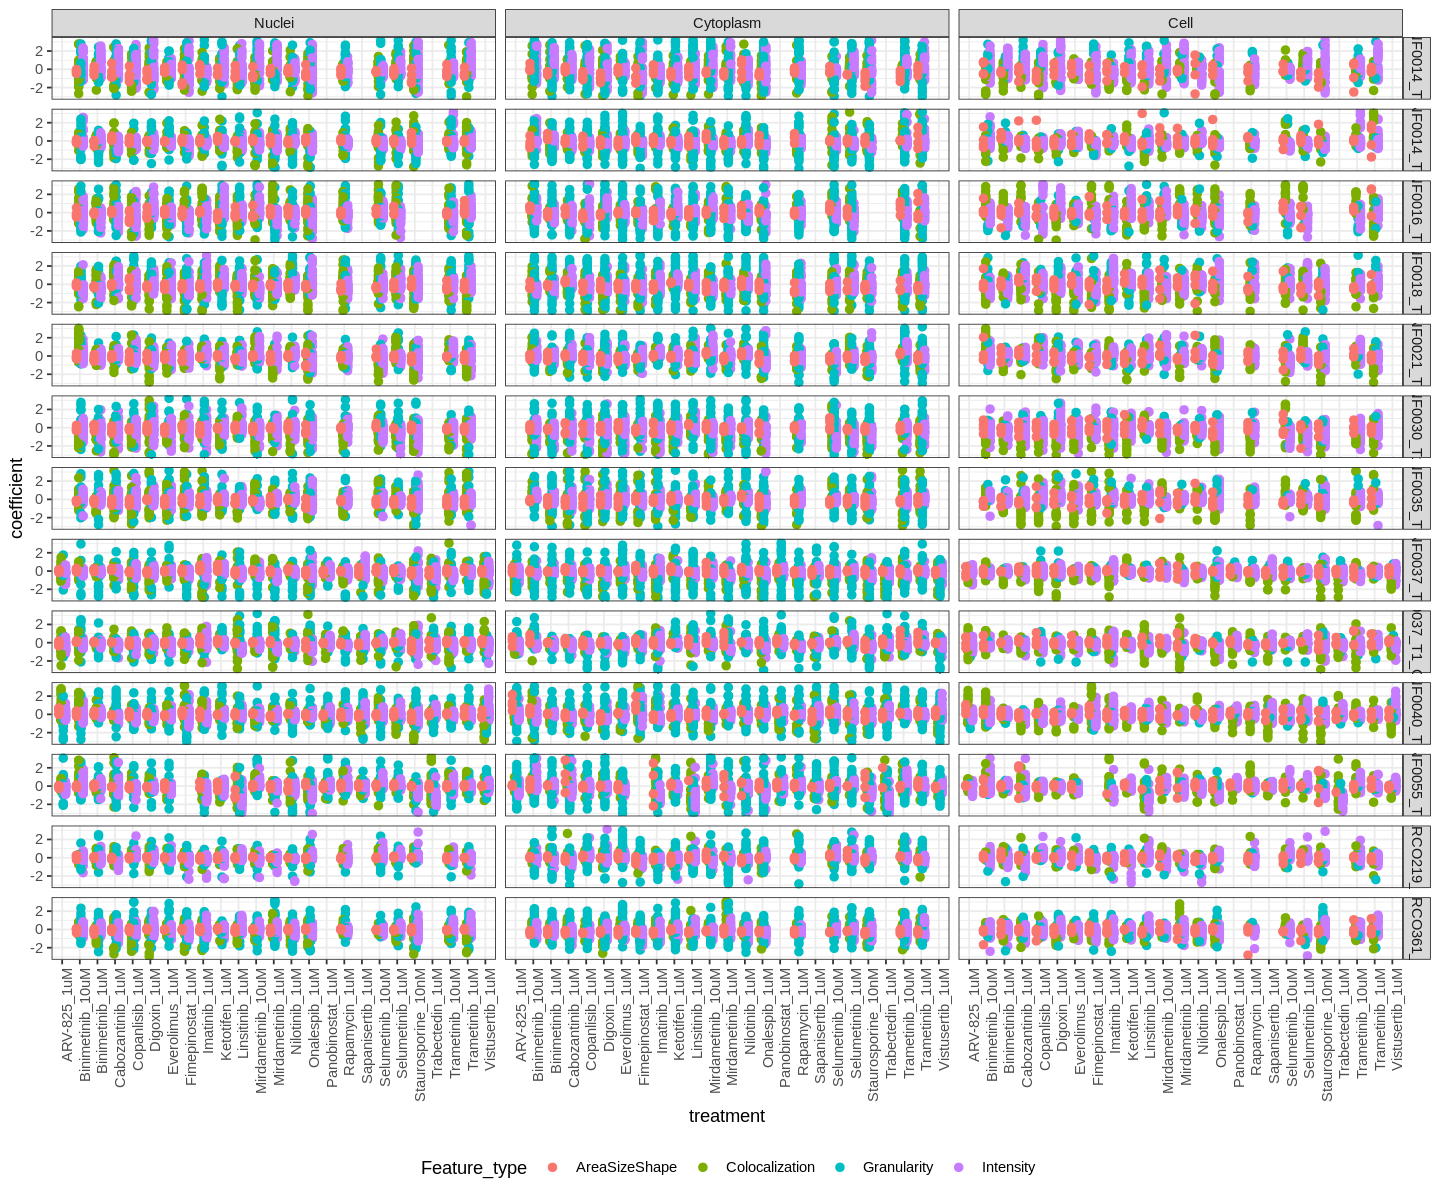

In [10]:
width <- 12
height <- 10
options(repr.plot.width = width, repr.plot.height = height)
coeff_plot <- (
    ggplot(sc_fs_lm_results_df,
        aes(x = treatment , y = coefficient, color = Feature_type))
    + geom_point(
        position = position_dodge(width = 0.5),
        size = 2
    )
    + theme_bw()
    + ylim(
        quantile(sc_fs_lm_results_df$coefficient, 0.01),
        quantile(sc_fs_lm_results_df$coefficient, 0.99)
        )
    + facet_grid(patient ~ Compartment)
    + theme(
        axis.text.x = element_text(angle = 90, hjust = 1),
        legend.position = "bottom"
    )

)
ggsave(
    filename = file.path(figures_path, "sc_linear_modeling_results_all_patients.png"),
    plot = coeff_plot,
    width = width,
    height = height
)
coeff_plot

In [11]:
patients <- unique(sc_fs_lm_results_df$patient)
for (patient_id in patients) {
    sc_fs_lm_results_df_patient <- sc_fs_lm_results_df %>%
        filter(patient == patient_id)
    # create a directory for the patient
    patient_file_path <- file.path(
            figures_path,
            patient_id
        )
        if (!dir.exists(patient_file_path)) {
            dir.create(patient_file_path, recursive = TRUE)
        }
    treatments <- unique(sc_fs_lm_results_df_patient$treatment)
    for (treatment_id in treatments) {
        sc_fs_lm_results_df_patient_drug <- sc_fs_lm_results_df_patient %>%
            filter(treatment == treatment_id)
        # drop the NA in Compartment
        sc_fs_lm_results_df_patient_drug <- sc_fs_lm_results_df_patient_drug %>%
            filter(!is.na(Compartment))
        # change NA in the Channel to None
        sc_fs_lm_results_df_patient_drug$Channel[is.na(sc_fs_lm_results_df_patient_drug$Channel)] <- "None"
        # isolate the Colocalization feature type
        sc_fs_lm_results_df_patient_drug_coloc <- sc_fs_lm_results_df_patient_drug %>%
            filter(Feature_type == "Colocalization")
        sc_fs_lm_results_df_patient_drug_all_other <- sc_fs_lm_results_df_patient_drug %>%
            filter(Feature_type != "Colocalization")
        
        width <- 10
        height <- 10
        options(repr.plot.width = width, repr.plot.height = height)
        no_coloc_plot <- (
            ggplot(sc_fs_lm_results_df_patient_drug_all_other,
                aes(x = Channel, y = coefficient, fill = Channel))
            + geom_boxplot(
                position = position_dodge(width = 0.5),
                size = 0.1,
            )
            + theme_bw()
            + labs(
                x = "Channel",
                y = "Coefficient",
                title = paste0(
                    "Linear modeling results for ", patient_id, " and ", treatment_id)
            )
            + ylim(
                quantile(sc_fs_lm_results_df_patient_drug_all_other$coefficient, 0.01),
                quantile(sc_fs_lm_results_df_patient_drug_all_other$coefficient, 0.99)
                )
            + facet_grid(Feature_type ~ Compartment)
            + theme(
                axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 14),
                axis.text.y = element_text(size = 14),
                axis.title.x = element_text(size = 14),
                axis.title.y = element_text(size = 14),
                plot.title = element_text(size = 14, hjust = 0.5),
                legend.text = element_text(size = 14),
                legend.title = element_text(size = 14),
                legend.position = "none",
                strip.text = element_text(size = 14),
            )
            + guides(
                fill = guide_legend(title = "")
            )
            # remove the x axis title
            + theme(axis.title.x = element_blank())
            
        )
        width <- 10
        height <- 4
        options(repr.plot.width = width, repr.plot.height = height)
        coloc_plot <- (
            ggplot(sc_fs_lm_results_df_patient_drug_coloc,
                aes(x = Channel, y = coefficient, fill = Channel))
            + geom_boxplot(
                position = position_dodge(width = 0.5),
                size = 0.1,
            )
            + theme_bw()
            + labs(
                x = "Channel",
                y = "Coefficient",
            )
            + ylim(
                quantile(sc_fs_lm_results_df_patient_drug_coloc$coefficient, 0.01),
                quantile(sc_fs_lm_results_df_patient_drug_coloc$coefficient, 0.99)
            )
            + facet_grid(Feature_type ~ Compartment)
            + theme(
                axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 14),
                axis.text.y = element_text(size = 14),
                axis.title.x = element_text(size = 14),
                axis.title.y = element_text(size = 14),
                plot.title = element_text(size = 14, hjust = 0.5),
                legend.text = element_text(size = 14),
                legend.title = element_text(size = 14),
                legend.position = "none",
                strip.text = element_text(size = 14),
            )
            + guides(
                fill = guide_legend(title = "")
            )
            
        )
        height <- 12
        width <- 10
        options(repr.plot.width = width, repr.plot.height = height)

        layout <- "
            AA
            AA
            AA
            BB
        "
        plot <- (
            no_coloc_plot + coloc_plot
            + plot_layout(design = layout)
        )
        
        
    
        ggsave(
            filename = file.path(
                patient_file_path,
                paste0(
                    "sc_linear_modeling_results_", 
                    patient_id,
                    "_",
                    treatment_id,
                    ".png"
                )
            ),
            plot = plot,
            width = width,
            height = height
        )
    }
}


Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
War

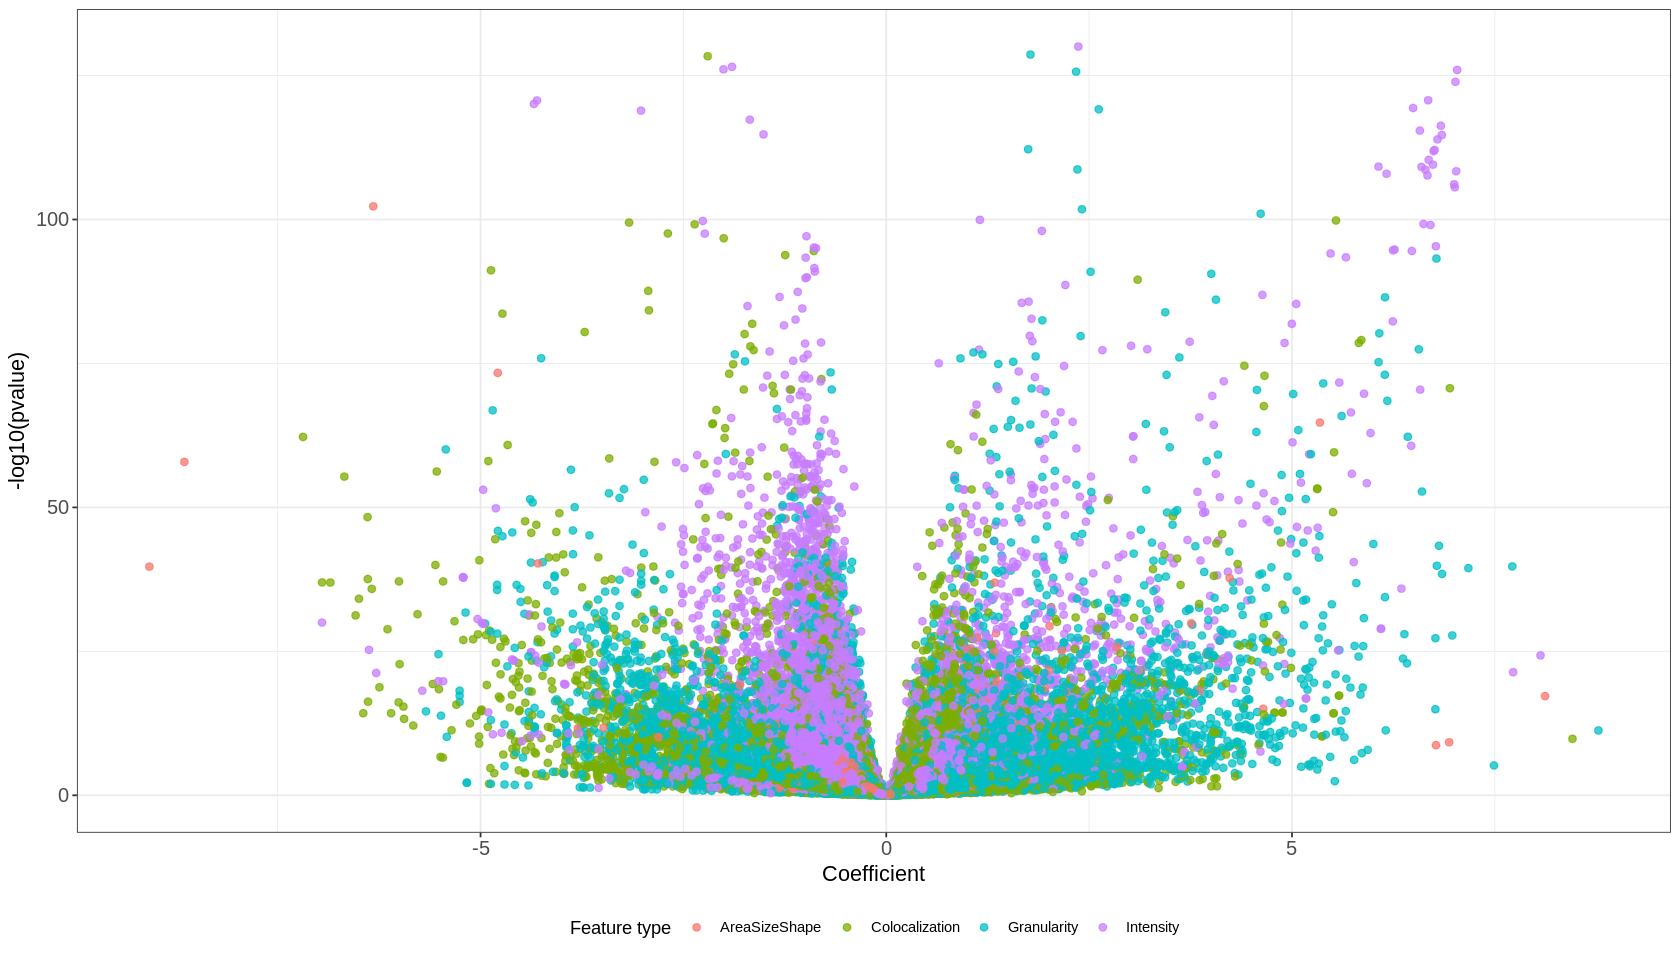

In [13]:
candidate_dfs <- c("sc_fs_lm_results_df", "organoid_fs_lm_results_df")
df_name <- candidate_dfs[candidate_dfs %in% ls()][1]
plot_df <- get(df_name)

p_col <- intersect(
    c("p_value", "pvalue", "p.val", "p_adj", "padj", "q_value", "qvalue"),
    names(plot_df)
)[1]

if (is.na(p_col)) {
    stop("No p-value column found in the selected data frame.")
}

plot_df <- plot_df %>%
    mutate(
        neg_log10_p = -log10(.data[[p_col]])
    ) %>%
    filter(is.finite(neg_log10_p), !is.na(coefficient))

facet_vars <- intersect(c("split", "shuffle", "model"), names(plot_df))
if (length(facet_vars) > 0) {
    plot_df$facet_group <- do.call(interaction, c(plot_df[facet_vars], list(sep = " | ", drop = TRUE)))
}

width <- 14
height <- 8
options(repr.plot.width = width, repr.plot.height = height)

p <- ggplot(plot_df, aes(x = coefficient, y = neg_log10_p, color = Feature_type)) +
    geom_point(alpha = 0.75, size = 1.8) +
    theme_bw() +
    labs(
        x = "Coefficient",
        y = paste0("-log10(", p_col, ")"),
        color = "Feature type"
    ) +
    theme(
        axis.text.x = element_text(size = 12),
        axis.text.y = element_text(size = 12),
        axis.title = element_text(size = 13),
        legend.position = "bottom"
    )

if (length(facet_vars) > 0) {
    p <- p + facet_wrap(~ facet_group)
}

ggsave(
    filename = file.path(figures_path, paste0(df_name, "_coef_vs_neglog10p.png")),
    plot = p,
    width = width,
    height = height
)

p

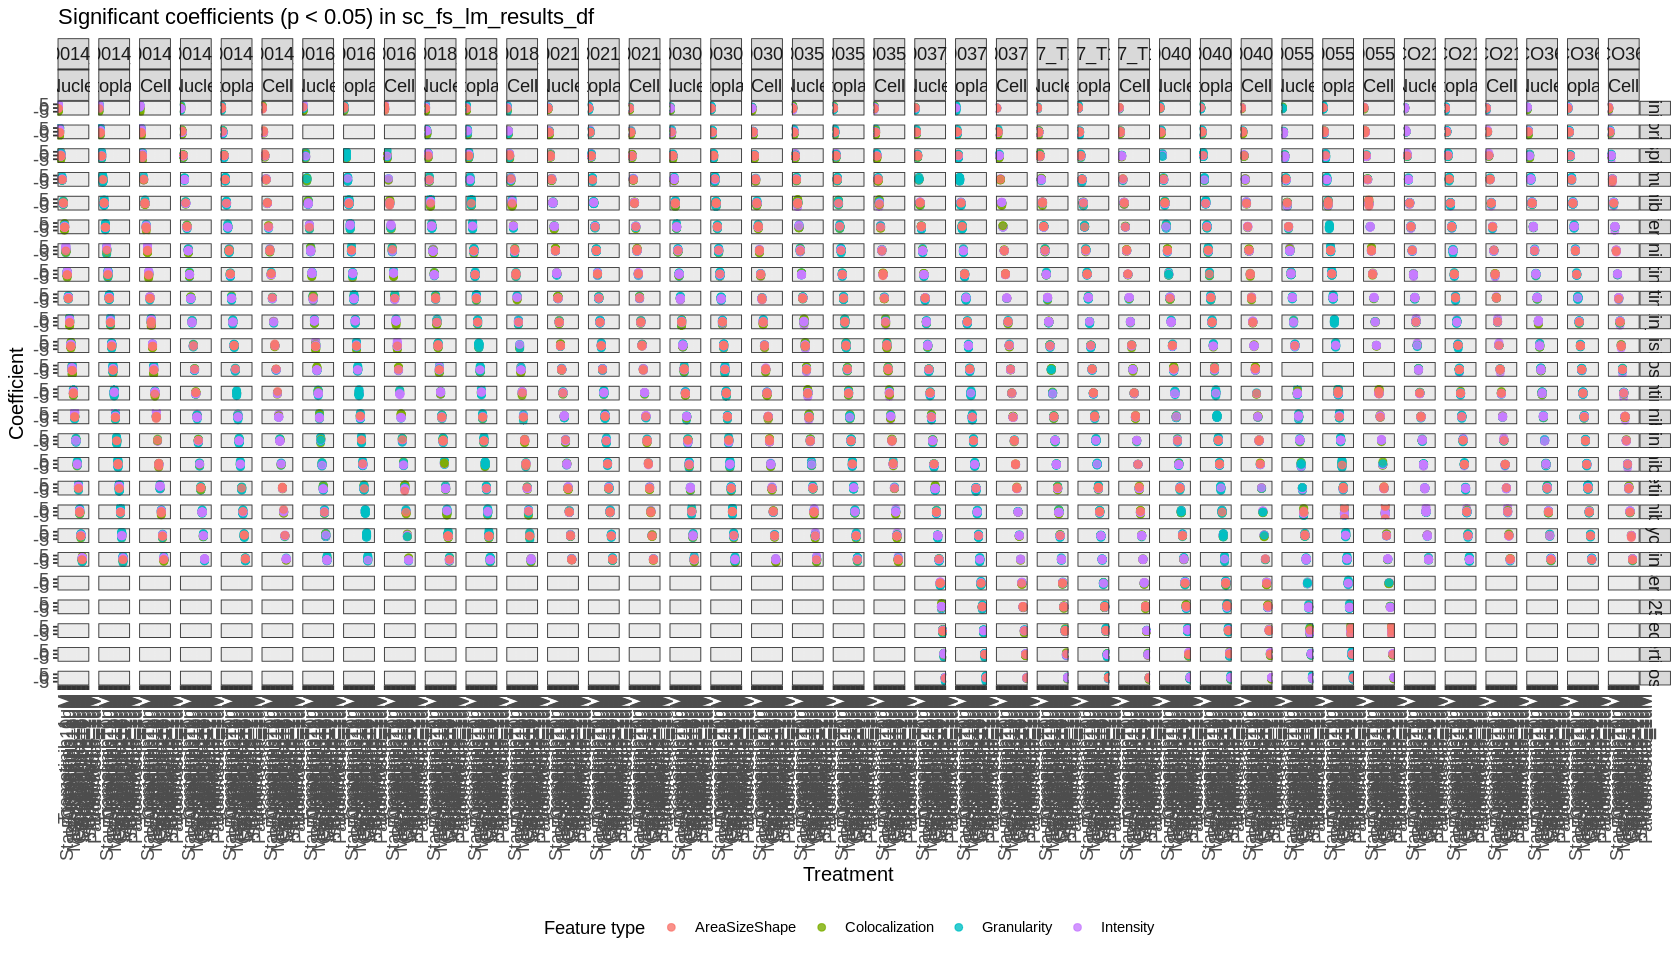

In [14]:
candidate_dfs <- c("sc_fs_lm_results_df", "organoid_fs_lm_results_df")
df_name <- candidate_dfs[candidate_dfs %in% ls()][1]
plot_df <- get(df_name)

p_col <- intersect(
    c("p_value", "pvalue", "p.val", "p_adj", "padj", "q_value", "qvalue"),
    names(plot_df)
)[1]

if (is.na(p_col)) {
    stop("No p-value column found in the selected data frame.")
}

sig_df <- plot_df %>%
    filter(!is.na(coefficient), !is.na(.data[[p_col]]), .data[[p_col]] < 0.05)

facet_vars <- intersect(c("treatment", "model", "patient", "Compartment"), names(sig_df))
if (length(facet_vars) == 0) {
    stop("No treatment/model/patient/Compartment column found for plotting.")
}

if ("treatment" %in% names(sig_df)) {
    sig_df$treatment <- factor(sig_df$treatment, levels = unique(sig_df$treatment))
}

width <- 14
height <- 8
options(repr.plot.width = width, repr.plot.height = height)

p <- ggplot(
    sig_df,
    aes(x = treatment, y = coefficient, color = Feature_type)
) +
    geom_point(
        position = position_jitter(width = 0.15, height = 0),
        alpha = 0.8,
        size = 1.8
    ) +
    theme_bw() +
    labs(
        x = "Treatment",
        y = "Coefficient",
        color = "Feature type",
        title = paste0("Significant coefficients (p < 0.05) in ", df_name)
    ) +
    theme(
        axis.text.x = element_text(angle = 90, hjust = 1, size = 11),
        axis.text.y = element_text(size = 11),
        axis.title = element_text(size = 12),
        legend.position = "bottom",
        strip.text = element_text(size = 11)
    )

if (length(facet_vars) > 1) {
    p <- p + facet_grid(reformulate(facet_vars[-1], facet_vars[1]))
} else if (length(facet_vars) == 1) {
    p <- p + facet_wrap(reformulate(facet_vars[1]))
}

ggsave(
    filename = file.path(figures_path, paste0(df_name, "_significant_coefficients.png")),
    plot = p,
    width = width,
    height = height
)

p